In [1]:
import pandas as pd
import plotly.express as px
import networkx as nx

In [2]:
# Здесь надо написать функцию, читающую файл data/openflights.txt, проводящую вычисления в соответствии с заданиями и сохраняющую результат в data/airport_indexes.txt.



In [3]:
cities = pd.read_csv("data/openflights_airports.txt", delimiter=" ")

In [4]:
air_res = pd.read_csv("data/airport_indexes.csv")

In [5]:
air_res.head()

,Airport ID,label
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0


In [6]:
cities2 = air_res.merge(cities, how='left', on="Airport ID")

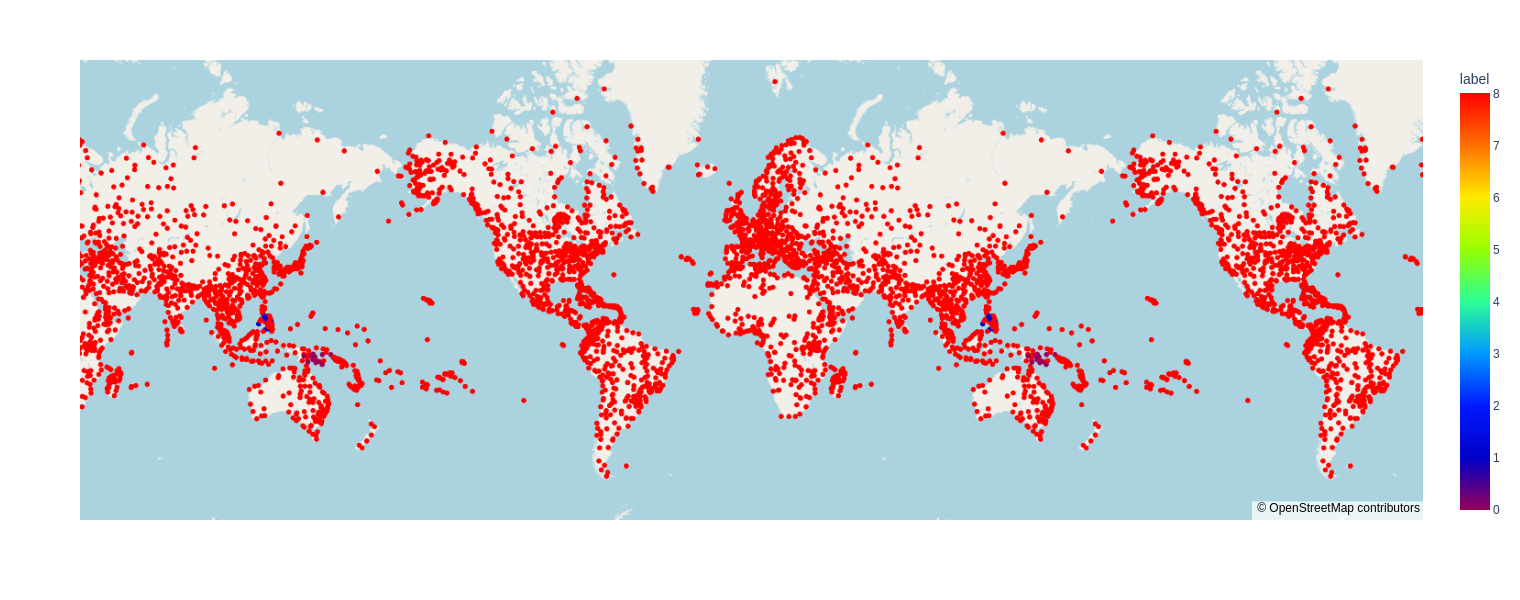

In [7]:
# Choose your color!
# clr_map = px.colors.qualitative.Alphabet
clr_map = px.colors.sequential.Rainbow
# clr_map = px.colors.sequential.algae

fig = px.scatter_map(cities2, lat="Latitude", lon="Longitude", color="label", 
                     map_style="open-street-map", 
                     color_continuous_scale=clr_map,
                     # color_continuous_scale="algae", # Choose your color!
                     zoom=0.5, width=900, height=600
                    )
fig.update_layout(showlegend=False)
fig.show()


In [2]:
import networkx as nx
from matplotlib import pyplot as plt
from tqdm.notebook import tqdm
import numpy as np
import pandas as pd
import itertools

/home/edward/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [54]:
df = pd.read_csv('data/hp_data3.csv')
df.head()

,entity1,entity2,freq,similarity
0,гарри,гермиона,9371,0.705580
1,гарри,драко,8603,0.619078
2,гарри,рон,6571,0.582779
3,гермиона,рон,4766,0.571588
4,гермиона,драко,3509,0.628281


In [55]:
# !!!
lg = nx.from_pandas_edgelist(df, source='entity1', target='entity2', edge_attr='similarity')


In [49]:
def draw_graph(g, feature_df):
    fig, ax = plt.subplots(1, figsize=(35, 20))
    nx.draw(g,
            ax=ax,
            with_labels=True,
            nodelist=feature_df["name"].values,
            node_size=feature_df["size"].values,
            pos=nx.kamada_kawai_layout(g),
            font_color='darkgreen',
            font_size=20,
            node_color=feature_df["color"].values,
            edge_color='gray',
            cmap=plt.cm.Pastel1,
           )
    plt.show()

In [6]:
color_df = pd.read_csv("data/hp_results.csv")

In [7]:
color_df.head()

,name,size,color
0,минерва,150,1.0
1,джордж_уизли,150,0.0
2,блэк,150,0.0
3,гермиона_грейнджер,150,0.0
4,фред,150,0.0


In [12]:
color_df["name"] = pd.Categorical(color_df['name'], categories=g.nodes, ordered=True)
result = color_df.sort_values('name').reset_index(drop=True)
result.head()

,name,size,color
0,гарри,150,2.0
1,гермиона,150,2.0
2,драко,150,2.0
3,рон,150,2.0
4,снейп,150,3.0


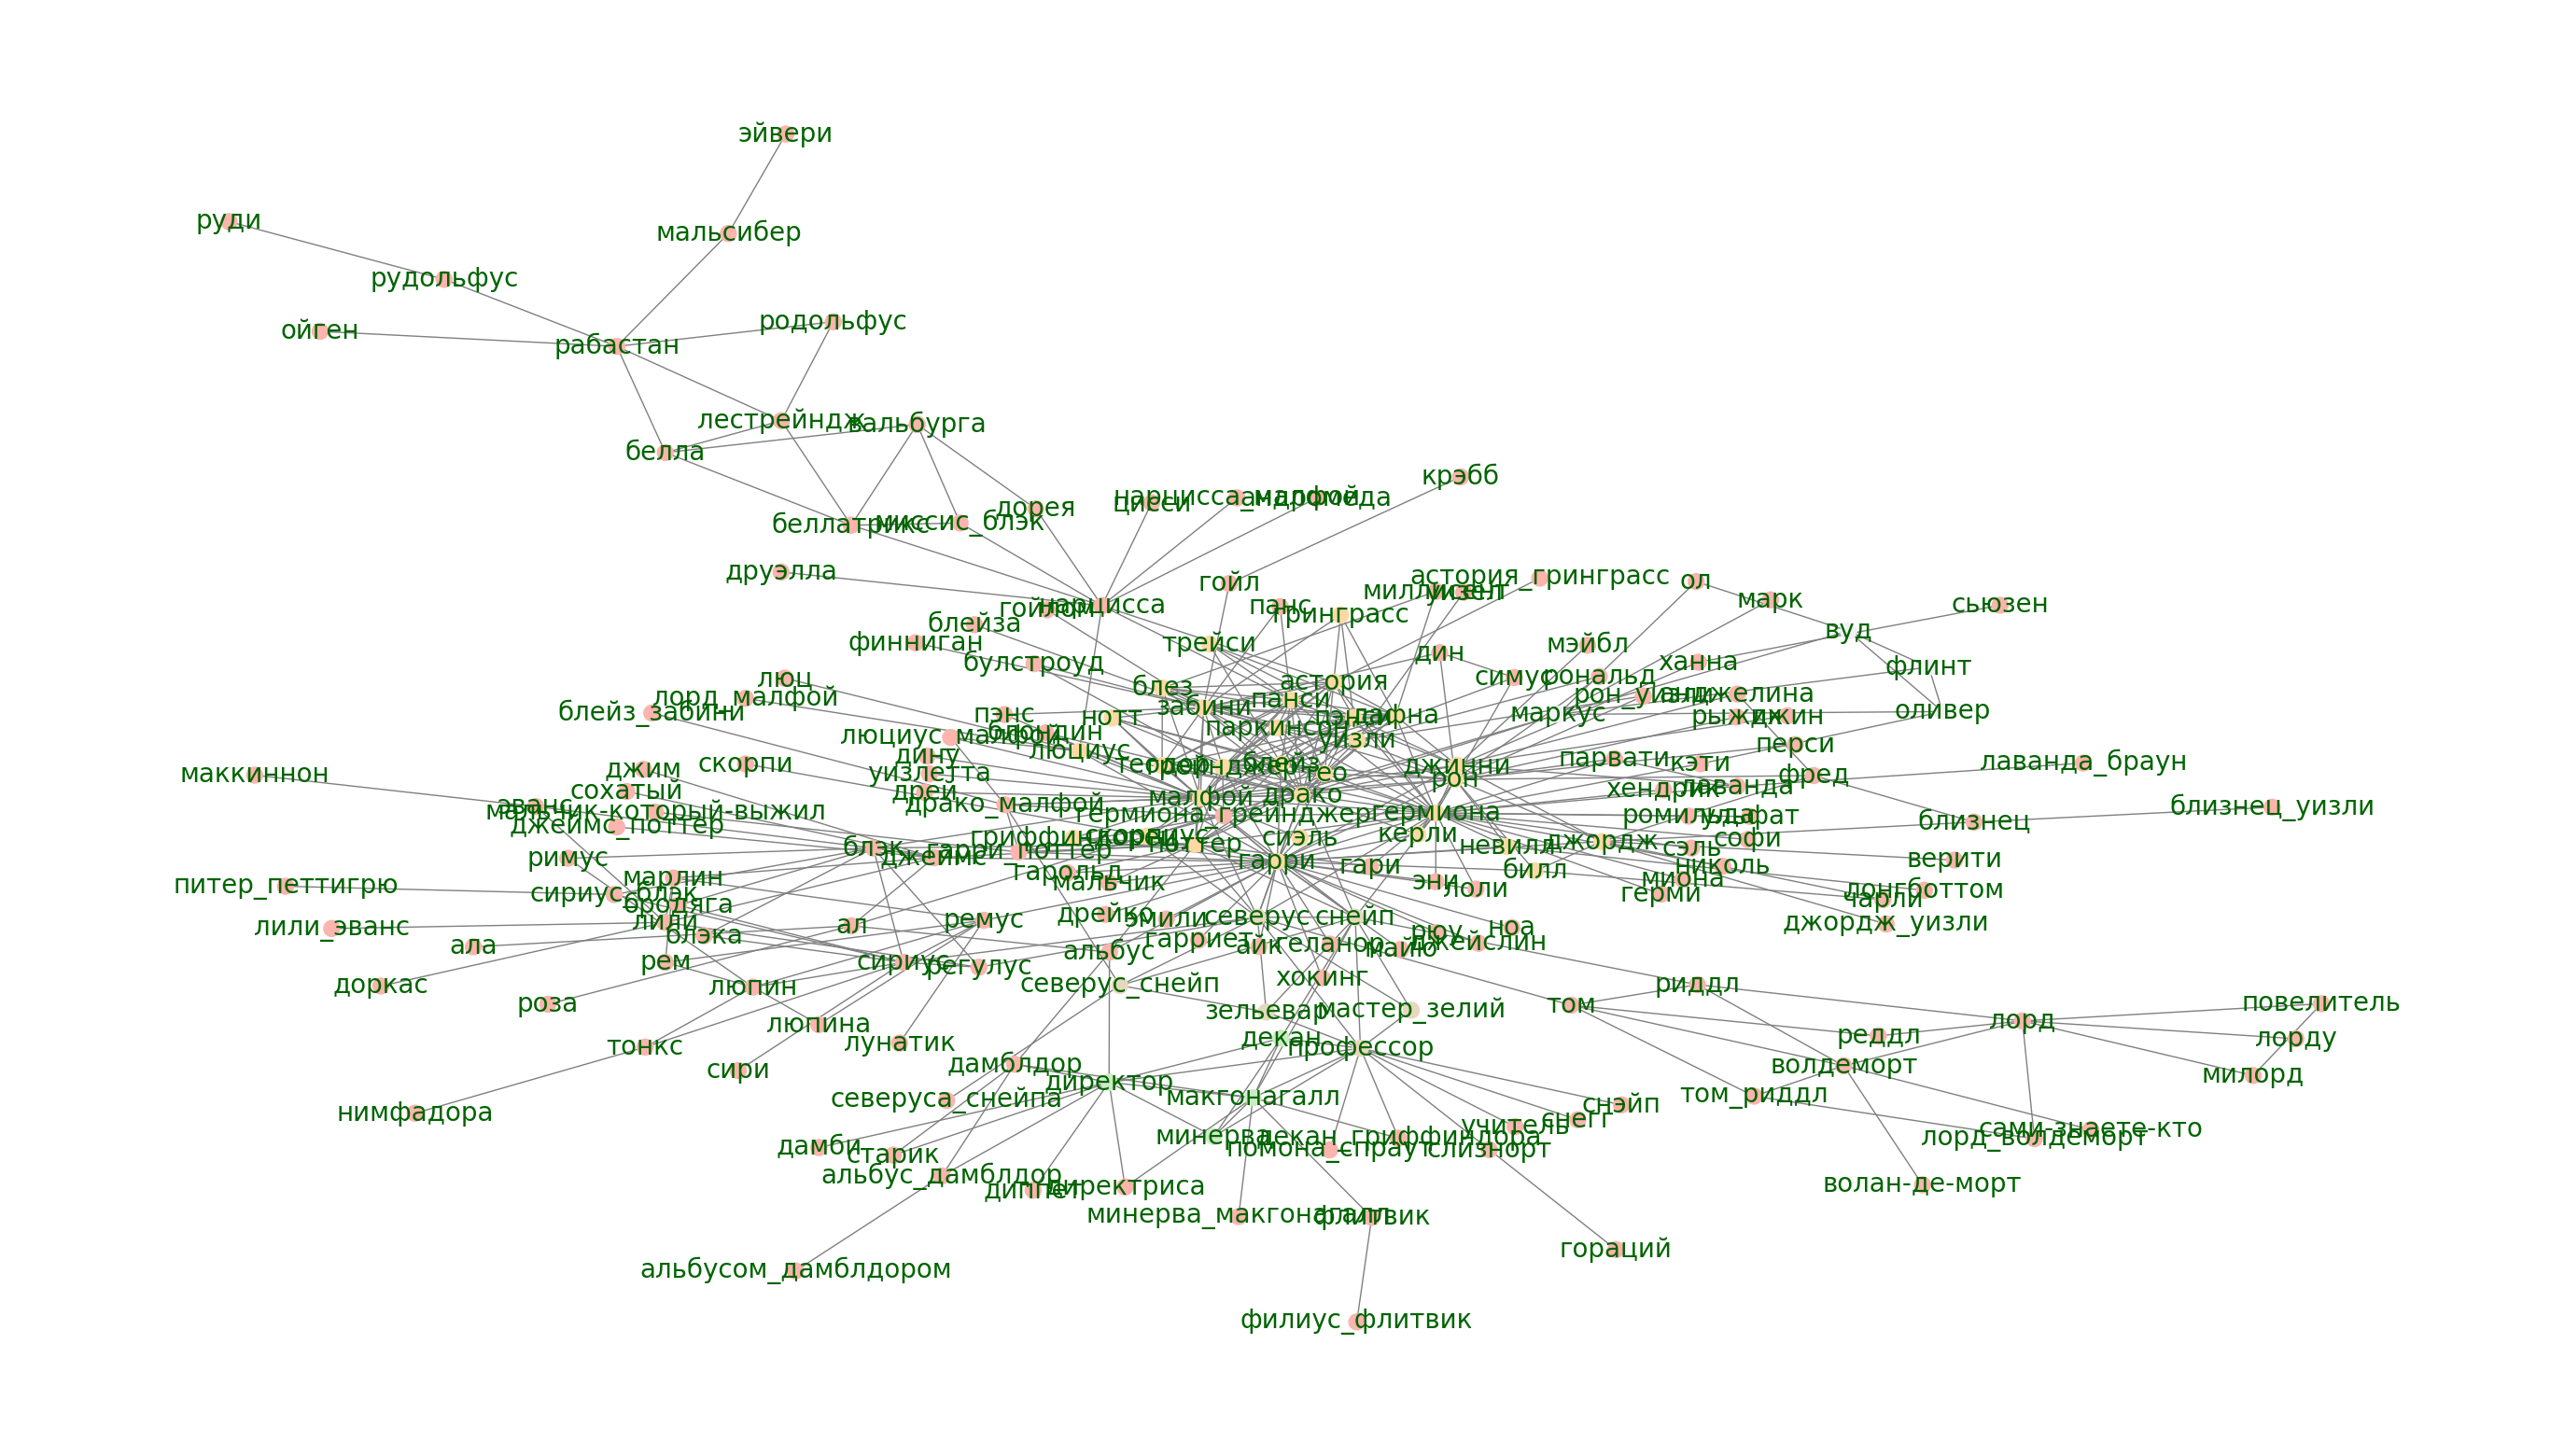

In [56]:
draw_graph(lg, color_df)